# MAFS5140 Multi-Factor Intraday Strategy Backtest

This notebook runs the backtest framework on the provided dataset.

In [1]:
# Step 1: Import modules
import sys, os

from data_feed import DataFeed
from engine import BacktestEngine
from evaluator import Evaluator
from strategy import Strategy

print('All modules imported successfully.')

All modules imported successfully.


In [2]:
# Step 2: Run backtest
data_path = 'train.parquet'

feed = DataFeed(data_path)
strategy = Strategy()
engine = BacktestEngine(data_feed=feed, strategy=strategy)

portfolio_returns = engine.run()

Starting backtest...


Backtest: 100%|█████████████████████| 178385/178385 [01:08<00:00, 2604.80step/s]


Backtest completed successfully.


In [3]:
# Step 3: Evaluate performance
evaluator = Evaluator(portfolio_returns, periods_per_year=252 * 78)
metrics = evaluator.generate_report()


--- Strategy Performance Report ---
Cumulative Return        : 664254.77%
Annualized Return        : 163.75%
Annualized Volatility    : 21.91%
Sharpe Ratio             : 7.47
Max Drawdown             : -28.67%
-----------------------------------


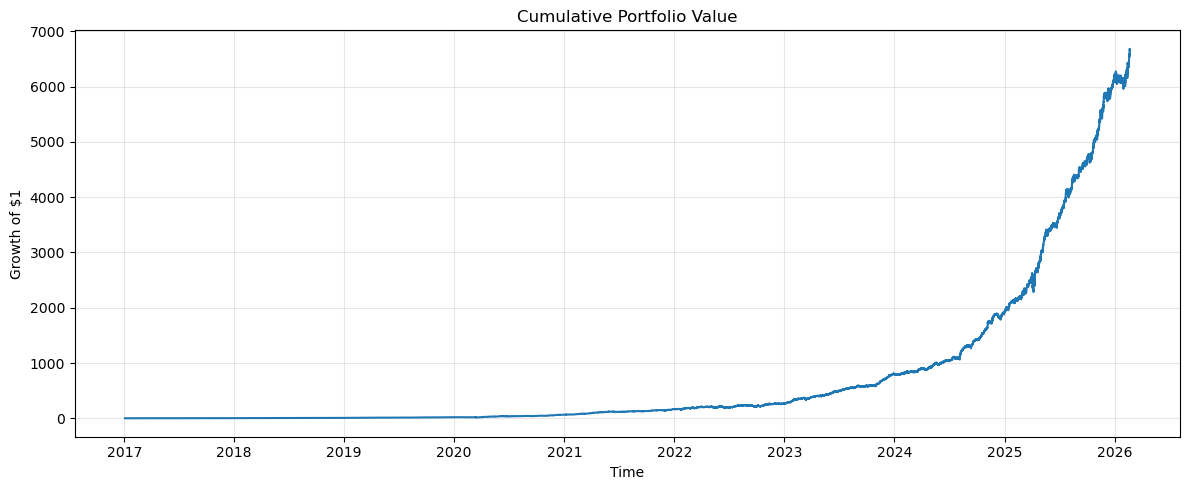

In [4]:
# Step 4: Plot cumulative return curve
import matplotlib.pyplot as plt

cumulative = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(cumulative.index, cumulative.values)
plt.title('Cumulative Portfolio Value')
plt.xlabel('Time')
plt.ylabel('Growth of $1')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()